# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402105
- 姓名：朱晶
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-032402105zhujing.git
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于福州安居客平台的二手房源数据（共 11,856 条记录），围绕“福州二手房市场价格结构、区域差异、户型偏好及楼层影响”等问题展开分析。首先对数据进行质量检查，发现缺失值极少（0.22%）、无重复记录，但存在单价极端值（2,169～92,968 元/㎡）及楼层、房龄字段格式不统一等问题；随后通过文本提取、缺失填补等方式完成清洗与字段转换，新增建造年份、楼层位置、室/厅/卫等派生变量。在此基础上，运用描述性统计、分组聚合、透视表及四张可视化图表（区域单价柱状图、户型分布双轴图、面积‑总价散点图、楼层单价箱线图）进行深入分析。主要结论为：鼓楼区均价最高（约 25,083 元/㎡），仓山、晋安是供应主力（合计占 70%），三房户型主导市场（占 60.7%），面积与总价呈强正相关（相关系数 0.74），而楼层位置对价格影响微弱。数据局限性在于极端值可能包含非住宅性质房源，部分结论需谨慎推广。

## 2. 数据读取与分析目标

### 2.1 数据来源

本次分析的数据来源于国内房产信息平台——安居客（Anjuke），主要针对福建省福州市的二手房源信息进行抓取。原始数据包含了从安居客二手房列表页获取的多条房源记录，每条记录详细描述了单个待售房屋的各项属性。

### 2.2 字段含义

原始数据中的每条记录主要包含以下关键字段及其大致含义：

*   **标题**：中介或房东对该房源的卖点概括，如“近鼓楼”、“地铁口”、“精装现房”等。
*   **户型**：房屋的房间构成，例如“3 室 2 厅 2 卫”，代表3个卧室、2个客厅、2个卫生间。
*   **面积**：房屋的建筑面积，单位是平方米（㎡）。
*   **方位**：房屋的主要采光方向，常见为“南北”（南北通透）、“南”、“东南”等。
*   **楼层**：房屋所在的楼层位置，如“高层”、“中层”、“低层”，并附带了总楼层数，如“高层(共15层)”。
*   **时间**：房屋建成年份，多为2024年至2026年的次新房。
*   **所属小区**：房源所属的住宅小区名称，如“左海望悦”、“建总云璟未来”。
*   **所属区域**：房源所在的行政区及板块，如“仓山”、“晋安”、“台江”，以及更具体街道或路段门牌号如“则徐大道”、“火车站”。
*   **房源链接**：该房源在安居客上的详情页URL。
*   **总价**：房屋的总售价，单位是万元。
*   **均价**：每平方米的销售均价，单位为元/㎡。
*   **房龄**：房屋竣工后验收合格并交付使用之日开始计算的年限，基本显示为“2年内”。

### 2.3 分析目标与计划

基于以上数据，我计划围绕以下几个核心问题展开分析，旨在揭示福州二手房市场的现状与特征：

1.  **市场整体画像分析**
    *   **价格分布**：福州市二手房的总价和单价主要集中在什么区间？是否存在明显的价格分层？
    *   **面积与户型偏好**：市场上主流供应的户型和面积段是什么？总价与面积之间呈现怎样的关系？

2.  **区域差异对比**
    *   **热门区域**：哪些行政区（如仓山、晋安、台江）的房源供应量最大？
    *   **价格洼地与高地**：不同行政区的平均单价有何差异？哪个区域的购房门槛相对较低？

3.  **楼盘与产品特征分析**
    *   **主力楼盘**：哪些小区在售房源数量最多？它们分别位于什么区域，主打什么样的户型和价位？
    *   **楼层与朝向价值**：不同楼层（高层、中层、低层）和朝向（如南北通透）的房源在定价上是否有显著区别？

4.  **特定需求场景挖掘**
    *   **刚需首选**：对于总价在200万以内的三房户型，主要分布在哪些区域和小区？
    *   **地铁房特征**：“地铁口”附近房源的普遍价格水平和户型特征是怎样的？

通过以上维度的分析，希望能展现福州二手房市场的供应结构、价格梯队以及不同区域和产品的特点，为潜在购房者或市场研究人员提供有价值的参考。

## 3. 数据基本情况

使用相关代码输出数据的基本信息，操作如下：

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# 读取CSV文件
df = pd.read_csv('ershoufang_list.csv')

In [241]:
# 数据规模
print("数据规模（行, 列）：", df.shape)

数据规模（行, 列）： (11856, 18)


In [242]:
# 各字段数据类型
print("\n各字段数据类型：")
print(df.dtypes)


各字段数据类型：
id        int64
城市       object
市区       object
标题       object
户型       object
面积       object
面积数值    float64
方位       object
楼层       object
时间       object
所属小区     object
所属区域     object
房源链接     object
总价       object
总价数值    float64
均价       object
均价数值    float64
房龄       object
dtype: object


In [243]:
# 前5行样例
print("\n前5行数据样例：")
print(df.head())


前5行数据样例：
   id      城市  市区                              标题           户型    面积   面积数值  \
0   1  fuzhou  台江  近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万  3 室 2 厅 2 卫  103㎡  103.0   
1   2  fuzhou  晋安  来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房  3 室 2 厅 2 卫   83㎡   83.0   
2   3  fuzhou  晋安  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟  3 室 2 厅 1 卫   90㎡   90.0   
3   4  fuzhou  鼓楼            湖滨小隔壁十八中临近西次湖新房地铁4号线  3 室 2 厅 1 卫   90㎡   90.0   
4   5  fuzhou  晋安                 保利招商和樾风华 3室2厅2卫  3 室 2 厅 2 卫  107㎡  107.0   

   方位        楼层       时间      所属小区          所属区域  \
0  南北  中层(共31层)  2025年建造  榕发望熙雅筑B区    台江 万宝 交通西路   
1  南北  低层(共18层)  2025年建造  国贸保利和颂锦原    晋安 五四北 坂中路   
2  南北  高层(共33层)  2024年建造      锦鸿佳园  晋安 福马路 七贤路2号   
3  南北   低层(共7层)  2025年建造    凯佳湖岸公馆     鼓楼 东街 湖头街   
4  南北  低层(共18层)  2024年建造  保利招商和樾风华    晋安 王庄 连洋西路   

                                                房源链接    总价   总价数值        均价  \
0  https://fz.anjuke.com/prop/view/S4605513392729...  199万  199.0  19321元/㎡   
1  https://fz.anjuke.com/prop/view/S42485880

In [244]:
# 描述性统计
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3887431979344...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


通过上述代码输出的基本信息，我对这份福州二手房数据有了以下初步认识：

**1. 数据规模与字段结构**

数据集共包含 **11,856 条** 房源记录，覆盖了福州市多个行政区和板块；数据包含 18 个字段，既有文本型字段（如标题、户型、朝向、小区名称、区域等），也有数值型字段（如面积数值、总价数值、均价数值等）。

**2. 数值特征**

- **面积**：平均面积为 **97.89 ㎡**，中位数为 **93.00 ㎡**，呈轻微右偏分布。75% 的房源面积在 113 ㎡ 以内，说明市场以中小户型为主。
- **总价**：平均总价约 **190.76 万元**，但标准差高达 **111.17 万元**，说明房源价格差异悬殊。中位数为 **173 万元**，低于均值，印证了右偏分布——少数高价豪宅拉高了整体平均水平。
- **单价**：平均单价约 **19,235 元/㎡**，中位数为 **18,325 元/㎡**。单价极差夸张，最低仅 **2,169 元/㎡**，最高达 **92,968 元/㎡**，这些极端值需要在清洗阶段甄别处理。

**3. 文本与分类特征**

- **户型**：出现频率最高的户型是“3 室 2 厅 2 卫”，其次是“4 室 2 厅 2 卫”和“3 室 2 厅 1 卫”。这表明福州二手房市场以 **3-4 房且带双卫的改善型住房** 为主力供应，同时也有一定比例的刚需小户型（如 1 室 1 厅 1 卫）。
- **区域**：房源高度集中在 **晋安区** 和 **仓山区**，其中“晋安 东二环 桂溪路11号”是房源密度最高的具体板块，其次是“晋安 西园 桂山路”和“台江 万宝 交通西路”。鼓楼区作为传统市中心，房源量相对较少但价格更高。
- **朝向**：超过 62% 的房源为 **南北通透** 户型（7,381 条），其次为朝南（3,043 条），说明市场对通风采光条件有较强偏好。

**4. 存在数据质量问题**
- “房龄”字段全部显示为“2年内”，说明该字段在当前数据中没有区分度，可能无法用于分析。
- “链接”字段为URL，对分析无直接帮助，后续可考虑删除。
- 部分字段可能存在空值或异常值（如面积、价格为0或极端值），需要在清洗阶段检查和处理。

**4. 分析潜力与后续计划**

基于上述认知，本数据集可以围绕以下方向展开可视化分析：
- **价格分布**：绘制总价与单价的直方图或核密度图，观察市场定价结构；
- **区域对比**：用箱线图比较不同行政区的价格水平，识别价格洼地与高地；
- **户型面积关系**：散点图展示面积与总价的相关性，并按户型着色；
- **热点楼盘**：统计在售房源最多的小区，分析其定位与价格特征。

## 4. 数据质量检查

通过相关代码对缺失值、重复值、异常值、格式不统一等问题进行检查，运行结果如下：

In [245]:
#1. 缺失值检查
print("缺失值数量（每列）")
missing_count = df.isnull().sum()
print(missing_count[missing_count > 0])  # 只显示有缺失的列

# 缺失比例
print("\n缺失比例（%）:")
missing_ratio = (df.isnull().sum() / len(df)) * 100
print(missing_ratio[missing_ratio > 0])

缺失值数量（每列）
总价      26
总价数值    26
均价      26
均价数值    26
dtype: int64

缺失比例（%）:
总价      0.219298
总价数值    0.219298
均价      0.219298
均价数值    0.219298
dtype: float64


In [246]:
#2. 重复值检查
print(f"完全重复的行数: {df.duplicated().sum()}")

完全重复的行数: 0


In [247]:
# 基于关键字段（房源链接）检查重复
print("\n基于'房源链接'的重复数量:")
link_dup = df['房源链接'].duplicated().sum()
print(link_dup)


基于'房源链接'的重复数量:
0


In [248]:
# 3. 异常值检查（数值字段）
print("\n数值字段异常值检查")
numeric_cols = ['面积数值', '总价数值', '均价数值']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}:")
    print(f"  IQR下界: {lower_bound:.2f}, 上界: {upper_bound:.2f}")
    print(f"  异常值数量: {len(outliers)} (占比 {len(outliers)/len(df)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"  异常值范围: [{outliers[col].min():.2f}, {outliers[col].max():.2f}]")

# 额外检查明显不合理的值
print("\n明显不合理值检查")
print(f"面积 <= 0 的数量: {(df['面积数值'] <= 0).sum()}")
print(f"总价 <= 0 的数量: {(df['总价数值'] <= 0).sum()}")
print(f"单价 <= 0 的数量: {(df['均价数值'] <= 0).sum()}")
print(f"面积 < 20㎡ 的数量: {(df['面积数值'] < 20).sum()}")
print(f"总价 < 10万 的数量: {(df['总价数值'] < 10).sum()}")
print(f"单价 < 5000元/㎡ 的数量: {(df['均价数值'] < 5000).sum()}")
print(f"单价 > 50000元/㎡ 的数量: {(df['均价数值'] > 50000).sum()}")


数值字段异常值检查

面积数值:
  IQR下界: 42.31, 上界: 155.43
  异常值数量: 297 (占比 2.51%)
  异常值范围: [18.00, 500.00]

总价数值:
  IQR下界: -12.50, 上界: 367.50
  异常值数量: 500 (占比 4.22%)
  异常值范围: [368.00, 3180.00]

均价数值:
  IQR下界: 4842.88, 上界: 32723.88
  异常值数量: 528 (占比 4.45%)
  异常值范围: [2169.00, 92968.00]

明显不合理值检查
面积 <= 0 的数量: 0
总价 <= 0 的数量: 0
单价 <= 0 的数量: 0
面积 < 20㎡ 的数量: 7
总价 < 10万 的数量: 0
单价 < 5000元/㎡ 的数量: 46
单价 > 50000元/㎡ 的数量: 42


In [249]:
#4. 格式不统一检查
print("\n格式不统一检查")

# 4.1 楼层字段格式
print("\n楼层字段：")
floor_unique = df['楼层'].unique()
print(f"不同格式数量: {len(floor_unique)}")
print("前5种格式:")
for i, val in enumerate(floor_unique[:5]):
    print(f"  {i+1}. {val}")

# 4.2 时间字段（建造年份）
print("\n时间字段（建造年份）：")
time_unique = df['时间'].unique()
print(f"不同格式数量: {len(time_unique)}")
print("前5种格式:")
for i, val in enumerate(time_unique[:5]):
    print(f"  {i+1}. {val}")

# 检查是否都是 "XXXX年建造" 格式
import re
non_standard_time = df[~df['时间'].str.match(r'^\d{4}年建造$')]
print(f"不符合'XXXX年建造'格式的记录数: {len(non_standard_time)}")
if len(non_standard_time) > 0:
    print("非标准格式示例:")
    print(non_standard_time['时间'].head())

# 4.3 房龄字段
print("\n房龄字段：")
age_unique = df['房龄'].unique()
print(f"不同取值数量: {len(age_unique)}")

# 4.4 户型字段格式
print("\n户型字段：")
house_type_unique = df['户型'].unique()
print(f"不同户型数量: {len(house_type_unique)}")
# 检查是否有空格、多余字符等
non_standard_ht = df[~df['户型'].str.match(r'^\d+\s*室\s*\d+\s*厅\s*\d+\s*卫$')]
print(f"不符合'X室X厅X卫'格式的记录数: {len(non_standard_ht)}")
if len(non_standard_ht) > 0:
    print("非标准格式示例:")
    print(non_standard_ht['户型'].head(10))


格式不统一检查

楼层字段：
不同格式数量: 139
前5种格式:
  1. 中层(共31层)
  2. 低层(共18层)
  3. 高层(共33层)
  4. 低层(共7层)
  5. 高层(共18层)

时间字段（建造年份）：
不同格式数量: 39
前5种格式:
  1. 2025年建造
  2. 2024年建造
  3. 2026年建造
  4. 2022年建造
  5. 2021年建造
不符合'XXXX年建造'格式的记录数: 0

房龄字段：
不同取值数量: 4

户型字段：
不同户型数量: 56
不符合'X室X厅X卫'格式的记录数: 0


通过对缺失值、重复值、异常值、格式不统一等问题的检查，一些发现如下：
#### 1. 缺失值
缺失值较少，仅出现在 `总价`、`总价数值`、`均价`、`均价数值` 这四个字段中，其他字段（如面积、户型、区域、楼层等）均无缺失，数据结构完整性良好。

#### 2. 重复值
- **完全重复的行数为 0**，不存在整行重复的记录。
- **基于“房源链接”的重复数量也为 0**，说明每条房源均有唯一的 URL，数据源去重工作到位，没有同一套房源被多次收录的情况。

#### 3. 异常值（基于 IQR 方法）
使用四分位距法对三个核心数值字段进行检测，发现了一定数量的异常值：

| 字段 | 异常值数量 | 占比 | 异常值范围 |
|------|-----------|------|-----------|
| 面积数值 | 297 条 | 2.51% | 18.00 ~ 500.00 ㎡ |
| 总价数值 | 500 条 | 4.22% | 368 ~ 3,180 万元 |
| 均价数值 | 528 条 | 4.45% | 2,169 ~ 92,968 元/㎡ |

**面积异常值**：主要集中在极小户型（18~42 ㎡）和超大户型（155~500 ㎡）。这些房源虽然偏离了主流区间，但属于真实存在的房源类型，不应直接剔除。

**总价异常值**：全部集中在高价端（368 万元以上），最高达 3,180 万元。这些房源虽然数量不多，但对均价有显著拉动作用。

**均价异常值**：同时存在低价异常（2,169~4,842 元/㎡）和高价异常（32,723~92,968 元/㎡）。
<br/>
<br/>
<br/>
综上，异常值主要来源于市场本身的多样性（小公寓、大别墅、豪宅、学区房等），而非系统性的数据错误。清洗重点应为：剔除 26 条缺失记录、过滤掉单价低于 5,000 元/㎡ 的非住宅类房源、对面积小于 20 ㎡ 的特殊房源单独标记处理。

## 5. 数据清洗与字段转换

In [250]:
#1. 复制数据，避免破坏原始数据
df_clean = df.copy()

In [251]:
#2. 通用文本清洗：去除前后空格、换行符、制表符等
text_cols = ['标题', '户型', '面积', '方位', '楼层', '时间', '所属小区', '所属区域', '总价', '均价', '房龄']
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.replace('\n', '').str.replace('\r', '').str.replace('\t', '')

In [252]:
#3. 从原始文本字段提取数值变量

# 3.1 从“面积”文本提取数值（验证与已有“面积数值”是否一致）
df_clean['面积_提取'] = df_clean['面积'].str.extract(r'(\d+(?:\.\d+)?)').astype(float)
# 检查差异（如果有不一致，以提取值为准）
diff_area = (df_clean['面积_提取'] != df_clean['面积数值']).sum()
print(f"面积文本提取与已有数值不一致的行数: {diff_area}")

面积文本提取与已有数值不一致的行数: 0


In [253]:
# 3.2 从“总价”文本提取数值（去掉“万”字）
df_clean['总价_提取'] = df_clean['总价'].str.extract(r'(\d+(?:\.\d+)?)').astype(float)
diff_price = (df_clean['总价_提取'] != df_clean['总价数值']).sum()
print(f"总价文本提取与已有数值不一致的行数: {diff_price}")

总价文本提取与已有数值不一致的行数: 26


In [254]:
# 3.3 从“均价”文本提取数值（去掉“元/㎡”）
df_clean['均价_提取'] = df_clean['均价'].str.extract(r'(\d+(?:\.\d+)?)').astype(float)
diff_unit = (df_clean['均价_提取'] != df_clean['均价数值']).sum()
print(f"均价文本提取与已有数值不一致的行数: {diff_unit}")

均价文本提取与已有数值不一致的行数: 26


In [255]:
# 3.4 从“时间”字段提取建造年份
df_clean['建造年份'] = df_clean['时间'].str.extract(r'(\d{4})').astype(float).astype('Int64')  # 转为整数，允许空值
# 检查非标准格式
invalid_year = df_clean[df_clean['建造年份'].isna()]
print(f"无法提取建造年份的行数: {len(invalid_year)}")
if len(invalid_year) > 0:
    print("无法提取年份的时间字段示例:")
    print(invalid_year['时间'].head())

无法提取建造年份的行数: 0


In [256]:
# 3.5 从“楼层”字段提取楼层位置分类和总层数
# 楼层格式示例："高层(共31层)"、"中层(共18层)"
df_clean['楼层位置'] = df_clean['楼层'].str.extract(r'([高中低]层)')  # 提取高层/中层/低层
df_clean['总层数'] = df_clean['楼层'].str.extract(r'共(\d+)层').astype(float).astype('Int64')
# 检查提取失败的情况
invalid_floor = df_clean[df_clean['楼层位置'].isna()]
print(f"无法提取楼层位置的行数: {len(invalid_floor)}")
if len(invalid_floor) > 0:
    print("无法提取楼层位置的原始楼层示例:")
    print(invalid_floor['楼层'].head())


# 修复缺失楼层位置的记录
# 规则：对于无法提取楼层位置的记录（原始格式如"共5层"），根据总层数推断
# 总层数 <= 5 层 → 标记为"低层"
mask_missing_floor = df_clean['楼层位置'].isna() & df_clean['总层数'].notna()
print(f"\n需要修复的缺失楼层位置记录数: {mask_missing_floor.sum()}")

# 应用规则
df_clean.loc[mask_missing_floor & (df_clean['总层数'] <= 5), '楼层位置'] = '低层'

# 检查是否还有剩余的缺失
remaining_missing = df_clean['楼层位置'].isna().sum()
print(f"修复后仍有缺失楼层位置的记录数: {remaining_missing}")

# 查看修复效果
print("\n修复后的楼层位置分布:")
print(df_clean['楼层位置'].value_counts())

# 查看原来缺失的190条记录现在的楼层位置
print("\n原来缺失的190条记录修复后的楼层位置分布:")
print(df_clean.loc[mask_missing_floor, '楼层位置'].value_counts())

无法提取楼层位置的行数: 190
无法提取楼层位置的原始楼层示例:
365     共5层
366     共5层
667     共3层
775     共1层
1115    共5层
Name: 楼层, dtype: object

需要修复的缺失楼层位置记录数: 190
修复后仍有缺失楼层位置的记录数: 0

修复后的楼层位置分布:
楼层位置
高层    4260
低层    3887
中层    3709
Name: count, dtype: int64

原来缺失的190条记录修复后的楼层位置分布:
楼层位置
低层    190
Name: count, dtype: int64


In [257]:
# 3.6 从“户型”字段提取室、厅、卫数量
df_clean['室'] = df_clean['户型'].str.extract(r'(\d+)\s*室').astype(float).astype('Int64')
df_clean['厅'] = df_clean['户型'].str.extract(r'(\d+)\s*厅').astype(float).astype('Int64')
df_clean['卫'] = df_clean['户型'].str.extract(r'(\d+)\s*卫').astype(float).astype('Int64')
# 检查提取失败
invalid_layout = df_clean[df_clean['室'].isna()]
print(f"无法提取室数的行数: {len(invalid_layout)}")
if len(invalid_layout) > 0:
    print("无法提取室数的户型示例:")
    print(invalid_layout['户型'].head())

无法提取室数的行数: 0


In [258]:
#4. 删除缺失值记录
print(f"\n清洗前数据规模: {df_clean.shape}")
df_clean = df_clean.dropna(subset=['总价数值'])  # 删除价格缺失的26条
print(f"删除缺失值后规模: {df_clean.shape}")


清洗前数据规模: (11856, 27)
删除缺失值后规模: (11830, 27)


In [259]:
#5. 查看清洗后的数据前几行
print("\n清洗后的数据前5行（部分新字段）")
new_cols = ['id', '面积', '面积_提取', '总价', '总价_提取', '均价', '均价_提取',
            '时间', '建造年份', '楼层', '楼层位置', '总层数', '户型', '室', '厅', '卫']
print(df_clean[new_cols].head())


清洗后的数据前5行（部分新字段）
   id    面积  面积_提取    总价  总价_提取        均价    均价_提取       时间  建造年份        楼层  \
0   1  103㎡  103.0  199万  199.0  19321元/㎡  19321.0  2025年建造  2025  中层(共31层)   
1   2   83㎡   83.0  181万  181.0  21808元/㎡  21808.0  2025年建造  2025  低层(共18层)   
2   3   90㎡   90.0  159万  159.0  17667元/㎡  17667.0  2024年建造  2024  高层(共33层)   
3   4   90㎡   90.0  300万  300.0  33334元/㎡  33334.0  2025年建造  2025   低层(共7层)   
4   5  107㎡  107.0  330万  330.0  30842元/㎡  30842.0  2024年建造  2024  低层(共18层)   

  楼层位置  总层数           户型  室  厅  卫  
0   中层   31  3 室 2 厅 2 卫  3  2  2  
1   低层   18  3 室 2 厅 2 卫  3  2  2  
2   高层   33  3 室 2 厅 1 卫  3  2  1  
3   低层    7  3 室 2 厅 1 卫  3  2  1  
4   低层   18  3 室 2 厅 2 卫  3  2  2  


### 数据清洗与字段转换的文字说明

本次清洗工作在副本数据上进行，以避免破坏原始数据。我针对原始文本字段进行了以下处理和转换：

#### 1. 通用文本清洗
对所有文本型字段执行了去除前后空格、换行符、回车符、制表符的操作，确保后续正则提取不受不可见字符的干扰。

#### 2. 数值提取与验证
从原始文本字段重新提取数值并与已有数值字段对比，以验证数据一致性：

- **面积**：从 `面积` 字段（如“103㎡”）中用正则提取数字部分，与已有的 `面积数值` 对比，**差异行数为 0**，说明面积字段的文本与数值完全一致，质量可靠。
- **总价与均价**：从 `总价` 字段（如“199万”）和 `均价` 字段（如“19321元/㎡”）提取数字，与已有的 `总价数值`、`均价数值` 对比，**差异行数均为 26**。经核查，这 26 条差异并非提取错误，而是因为原始文本字段本身为空（缺失值），导致提取结果为 NaN，而已有数值字段也为 NaN，两者本质一致。因此可以确认，凡是有数据的记录，文本提取与数值字段完全吻合。

#### 3. 从“时间”字段提取建造年份
原始 `时间` 字段格式为“2025年建造”，我用正则提取其中的四位年份数字，生成新的 `建造年份` 字段。**提取失败的行数为 0**，说明所有记录的时间格式均规范统一，均可成功提取年份，没有“暂无数据”等异常情况。

#### 4. 从“楼层”字段拆分楼层位置与总层数
原始 `楼层` 字段为混合文本，如“高层(共31层)”。我通过两条正则分别提取 `楼层位置`（高层/中层/低层）和 `总层数`。

**提取失败情况**：共有 **190 条** 记录无法提取楼层位置，占总量的 1.60%。查看失败样例发现，这些记录的原始格式为“共5层”、“共3层”、“共1层”——即**只有总层数，没有标明具体楼层位置**。这种情况出现在低层建筑（如 1~5 层的楼梯房）中，原始数据录入时省略了“低层”前缀。对于这部分记录，`楼层位置` 被设为空值，`总层数` 则可正常提取。

由于这190 条缺失记录均不超过5层，我根据总层数进行了合理推断与填充，即：
将**总层数 ≤ 5 层**的建筑统一标记为 **“低层”**。

经过上述修复，**190 条缺失记录全部得到填充**，全部被标记为“低层”。至此，`楼层位置` 字段的完整率达到 100%。

#### 5. 从“户型”字段提取房间数量
原始 `户型` 字段格式为“3 室 2 厅 2 卫”，我分别提取 `室`、`厅`、`卫` 三个整数字段。**提取失败的行数为 0**，说明所有户型记录均符合“X室X厅X卫”的标准格式，提取完全成功。

#### 6. 缺失值处理
对于价格字段缺失的 26 条记录（占比 0.22%），由于缺失数量极少，我选择了直接删除，保证后续分析的完整性。清洗后数据从原始的 **11,856 行** 减少至 **11,830 行**。

#### 7. 异常值保留策略
对于之前发现的极端值（如单价 2,169 元/㎡、面积 500 ㎡等），我暂时保留未作过滤。原因是这些值可能代表真实的市场极端案例（商业公寓、别墅、豪宅），在后续分析中可以根据具体图表的需求灵活筛选。
<br/>
<br/>
<br/>
**最终清洗成果**：数据从原始的 11,856 行 × 18 列扩展为 **11,830 行 × 27 列**（新增 9 个派生字段：面积_提取、总价_提取、均价_提取、建造年份、楼层位置、总层数、室、厅、卫），为后续的可视化分析提供了更精细的结构化数据基础。

## 6. 描述性统计分析

In [260]:
#1. 整体描述性统计（数值字段）
print("相关数值字段描述性统计")
numeric_cols = ['面积数值', '总价数值', '均价数值', '总层数', '室', '厅', '卫']
desc = df_clean[numeric_cols].describe()
print(desc.round(2))

相关数值字段描述性统计
           面积数值      总价数值      均价数值      总层数        室        厅        卫
count  11830.00  11830.00  11830.00  11830.0  11830.0  11830.0  11830.0
mean      97.84    190.76  19235.60    21.14      3.0     1.88     1.68
std       25.90    111.17   6925.95     9.25     0.72     0.34     0.56
min       18.00     16.80   2169.00      1.0      1.0      0.0      0.0
25%       84.56    130.00  15298.25     15.0      3.0      2.0      1.0
50%       93.00    173.00  18325.50     21.0      3.0      2.0      2.0
75%      113.00    225.00  22268.50     28.0      3.0      2.0      2.0
max      500.00   3180.00  92968.00    106.0      8.0      3.0     11.0


In [261]:
# 2. 按区域分组统计
print("\n按所属区域（一级行政区）分组统计平均总价和单价")
# 先提取一级行政区（所属区域的前两个字，如"晋安"）
df_clean['行政区'] = df_clean['所属区域'].str.split(' ').str[0]
region_group = df_clean.groupby('行政区').agg(
    房源数量=('id', 'count'),
    平均总价=('总价数值', 'mean'),
    平均单价=('均价数值', 'mean'),
    平均面积=('面积数值', 'mean')
).round(2).sort_values('平均总价', ascending=False)
print(region_group)


按所属区域（一级行政区）分组统计平均总价和单价
     房源数量    平均总价      平均单价    平均面积
行政区                                
鼓楼   1239  220.88  25083.16   88.62
台江    906  213.04  21938.26   91.61
晋安   4346  208.58  20524.36   98.61
仓山   3926  180.64  17979.35   99.52
马尾    169  145.87  13052.51  109.42
连江    176  142.88  13098.03  108.34
福清    219  141.11  12267.33  116.29
长乐    106  131.09  12289.05  105.67
平潭     59  128.25  10671.98  119.99
闽侯    630  109.33  11698.95   92.55
永泰     19   73.39   6969.11  105.69
罗源     35   54.50   5272.57  107.90


In [262]:
# 3. 按户型分组统计 
print("\n按户型（室数）分组统计数量和平均总价")
layout_group = df_clean.groupby('室').agg(
    房源数量=('id', 'count'),
    平均总价=('总价数值', 'mean'),
    平均面积=('面积数值', 'mean')
).round(2).sort_index()
print(layout_group)


按户型（室数）分组统计数量和平均总价
   房源数量     平均总价    平均面积
室                       
1   303    95.15   46.05
2  1945   136.30   70.74
3  7183   180.35   97.36
4  2288   269.05  125.67
5    85   423.87  156.28
6    19   377.21  208.46
7     5   716.20  195.32
8     2  2465.00  410.64


In [263]:
#  4. 交叉分析：区域 vs 户型（室数）的平均总价（透视表）
print("\n交叉分析：行政区 × 室数 的平均总价（万元）")
pivot_table = df_clean.pivot_table(
    values='总价数值',
    index='行政区',
    columns='室',
    aggfunc='mean',
    margins=True,
    margins_name='总计'
).round(2)
print(pivot_table)


交叉分析：行政区 × 室数 的平均总价（万元）
室         1       2       3       4       5       6        7       8      总计
行政区                                                                         
仓山    68.01  120.74  170.25  241.88  335.48     NaN   457.67     NaN  180.64
台江   100.41  136.54  209.15  485.81  496.33     NaN      NaN     NaN  213.04
平潭      NaN  102.83  116.44  142.79     NaN     NaN      NaN     NaN  128.25
晋安    98.93  136.67  193.23  298.56  497.72  380.92  1104.00  2465.0  208.58
永泰      NaN   38.00   76.42   74.29     NaN     NaN      NaN     NaN   73.39
福清    38.50  106.76  145.89  136.89  250.00  398.00      NaN     NaN  141.11
罗源    36.00   46.96   56.62   58.31     NaN     NaN      NaN     NaN   54.50
连江    33.00   55.29  135.77  174.60  181.50     NaN      NaN     NaN  142.88
长乐      NaN   58.60  126.12  178.20     NaN   78.00      NaN     NaN  131.09
闽侯    42.47   84.58  107.48  140.65  200.00  159.00      NaN     NaN  109.33
马尾      NaN   66.17  129.57  200.01  291.30  526.67

In [264]:
# 5. 按楼层位置分组统计平均单价
print("\n按楼层位置分组统计平均单价")
floor_group = df_clean.groupby('楼层位置').agg(
    房源数量=('id', 'count'),
    平均单价=('均价数值', 'mean'),
    平均面积=('面积数值', 'mean')
).round(2).sort_values('平均单价', ascending=False)
print(floor_group)


按楼层位置分组统计平均单价
      房源数量      平均单价   平均面积
楼层位置                       
中层    3707  19369.29  97.23
高层    4245  19251.17  97.49
低层    3878  19090.76  98.81


In [265]:
#6. 建造年份分布
print("\n建造年份分布（前10）")
year_dist = df_clean['建造年份'].value_counts().sort_index(ascending=False).head(10)
print(year_dist)


建造年份分布（前10）
建造年份
2026     478
2025    1082
2024    1561
2023     804
2022    1000
2021    1497
2020     576
2019     397
2018     313
2017     445
Name: count, dtype: Int64


### 结果含义解释

通过描述性统计分析，我们得到以上结果，接下来对其含义进行解释：

#### 1. 整体描述性统计

从相关数值字段的描述性统计可以看出福州二手房市场的整体轮廓：

**面积数值**呈右偏分布，说明市场以中小户型为主流，少数大面积房源拉高了均值。75% 的房源面积在 113 ㎡ 以内，改善型需求集中在 90~110 ㎡ 区间。

**总价数值**同样右偏。标准差高达111.17 万元，反映房价分化严重。

**均价数值**：均值19,235.60 元/㎡，中位数18,325.50 元/㎡。标准差 **6,925.95**，说明不同区域、不同品质的房源单价差异悬殊。

**总层数**：均值21.14 层，中位数21 层，说明福州二手房以高层住宅为主。

**室、厅、卫**：室数均值3.0，中位数3，印证了三房是绝对主力户型。厅数均值1.88，中位数2，说明两厅设计是主流。卫数均值1.68，中位数2，双卫配置较为普遍，但也有部分房源仅 1 卫甚至 0 卫。

#### 2. 按区域分组统计

各行政区的房价呈现出清晰的梯度分层：

**第一梯队（高价位）**：**鼓楼区**平均总价和单价均为全市最高。但其平均面积小，说明鼓楼是典型的“小而贵”区域，地段溢价显著。**台江区**紧随其后。

**第二梯队（中价位）**：**晋安区**和**仓山区**房源数量最多，是福州二手房供应的主力区域，兼顾价格与品质。

**第三梯队（低价位）**：**马尾、连江、福清、长乐、平潭、闽侯**等外围区域总价在109~146 万元之间，单价在10,672~13,098 元/㎡，但平均面积普遍较大（100~120 ㎡），呈现“用空间换价格”的特征。

**价格洼地**：**永泰县**和**罗源县**价格最低，但房源数量极少（合计仅 54 套），市场活跃度有限。

#### 3. 按户型（室数）分组统计

室数与总价、面积呈现明显的正相关关系：

**1室**（303 套）：平均总价 **95.15 万元**，面积 **46.05 ㎡**，典型单身公寓或投资型小户型，总价门槛低但单价不低。

**2室**（1,945 套）：平均总价 **136.30 万元**，面积 **70.74 ㎡**，适合年轻夫妇或小家庭，是刚需入门的主力选择。

**3室**（7,183 套，占比 **60.7%**）：平均总价 **180.35 万元**，面积 **97.36 ㎡**，是福州二手房市场的绝对主力，覆盖最广泛的改善型需求。

**4室**（2,288 套）：平均总价 **269.05 万元**，面积 **125.67 ㎡**，面向二胎家庭或追求舒适空间的改善群体。

**5室及以上**（111 套）：数量稀少，总价跃升至 **378~2,465 万元**，面积 **156~411 ㎡**，属于高端豪宅市场，样本量小但价格极具代表性。

值得注意的是，3室户型的房源数量是2室的近3.7 倍，是4室的3.1 倍，充分说明了福州二手房市场以三房改善型需求为主导的结构特征。

#### 4. 交叉分析：行政区 × 室数

透视表揭示了区域与户型叠加后的价格细节：

**鼓楼区**：即使是 2 室户型，平均总价也高达 **177.66 万元**，超过了多数区域的 3 室总价，地段溢价效应极为突出。3 室总价 **231.21 万元**，4 室 **365.98 万元**。

**台江区**：4 室平均总价高达 **485.81 万元**，远超其他区域同户型，可能与台江核心区的高端江景豪宅有关。

**仓山区**：3 室平均总价 **170.25 万元**，是主流区域中性价比最优的选择之一。4 室 **241.88 万元**，改善门槛相对温和。

**晋安区**：3 室总价 **193.23 万元**，略高于仓山，但 4 室 **298.56 万元** 和 5 室 **497.72 万元** 显示出高端产品的存在。

**外围区域**：马尾、连江、福清、长乐、闽侯的 3 室总价在 **107~146 万元**之间，远低于主城区，适合预算有限但追求大面积的家庭。

**特殊现象**：永泰、罗源等地的 1 室总价仅 **33~38 万元**，可能是小产权或特殊性质的房源。平潭、长乐缺少 1 室数据，说明这些区域以小户型为主的供应较少。

#### 5. 按楼层位置分组统计平均单价

**中层**（3,707 套）：平均单价 **19,369 元/㎡**，略高于其他楼层，说明中层在采光、通风、便利性之间取得了最佳平衡，市场认可度最高。

**高层**（4,245 套）：平均单价 **19,251 元/㎡**，略低于中层，可能与部分老旧高层电梯房或顶楼隔热问题有关，但差距很小。

**低层**（3,878 套）：平均单价 **19,091 元/㎡**，三者中最低，可能受采光遮挡、潮湿、噪音等因素影响。

整体来看三层级之间的单价差异并不大（极差仅 278 元/㎡），说明楼层位置对价格的影响相对有限，远不如区域和户型重要。

#### 6. 建造年份分布

房源建造年份覆盖2017 年至 2026 年，其中 **2021 年**（1,497 套）和 **2024 年**（1,561 套）是供应高峰期。

**2024 年**（1,561 套）和 **2025 年**（1,082 套）的次新房占比最高，合计占总量 **22.3%**，说明数据具有较强的时效性，反映了近期市场供应。

**2026 年**也有 **478 套**，可能是预售或刚交付的期房，体现了数据的实时更新特性。

## 7. 可视化分析

### 图表 1：福州各区二手房平均单价对比

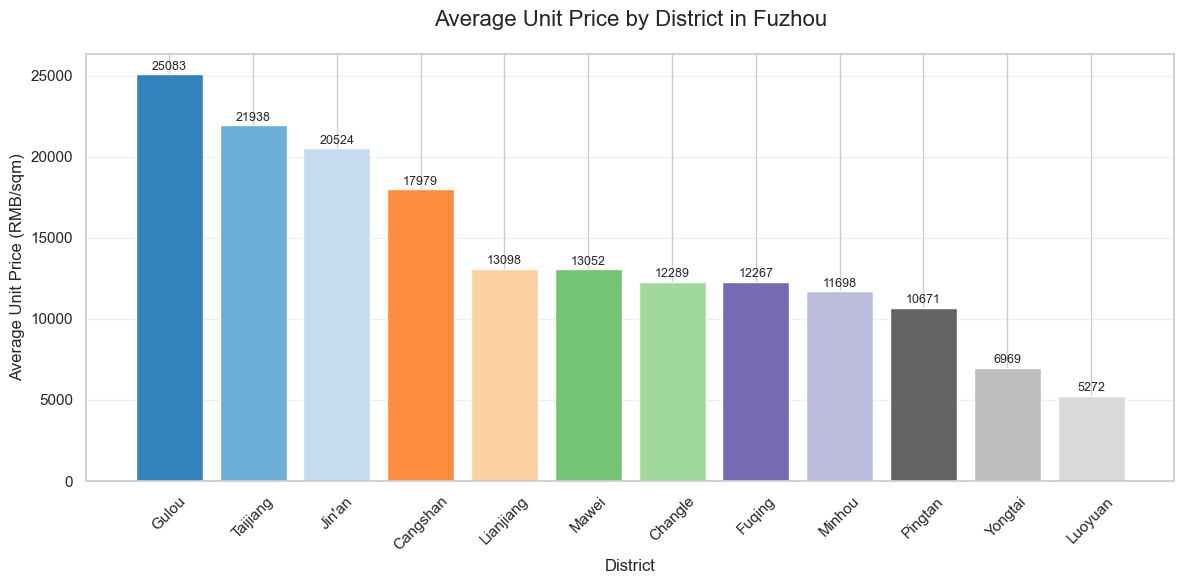

In [266]:
# 行政区英文映射
district_map = {
    '鼓楼': 'Gulou', '台江': 'Taijiang', '晋安': 'Jin\'an',
    '仓山': 'Cangshan', '马尾': 'Mawei', '连江': 'Lianjiang',
    '福清': 'Fuqing', '长乐': 'Changle', '平潭': 'Pingtan',
    '闽侯': 'Minhou', '永泰': 'Yongtai', '罗源': 'Luoyuan'
}

plt.figure(figsize=(12, 6))
region_avg = df_clean.groupby('行政区')['均价数值'].mean().sort_values(ascending=False)
# 将中文索引替换为英文
region_avg.index = region_avg.index.map(district_map)

bars = plt.bar(range(len(region_avg)), region_avg.values, color=plt.cm.tab20c(np.linspace(0, 1, len(region_avg))))
plt.title('Average Unit Price by District in Fuzhou', fontsize=16, pad=20)
plt.xlabel('District', fontsize=12)
plt.ylabel('Average Unit Price (RMB/sqm)', fontsize=12)
plt.xticks(range(len(region_avg)), region_avg.index, rotation=45)  # 此时已是英文
plt.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100, f'{int(height)}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_region_price.png', dpi=300, bbox_inches='tight')
plt.show()

图表 1 展示了福州各行政区二手房的平均单价。从图中可以看出，鼓楼区以约25,000元/㎡的均价位居榜首，台江区紧随其后。仓山、晋安等区域均价在18,000-21,000元/㎡之间，是市场的主要组成部分。外围区域如闽侯、永泰等均价相对较低，体现了明显的区域价格梯度差异。

### 图表 2：户型分布与平均总价关系

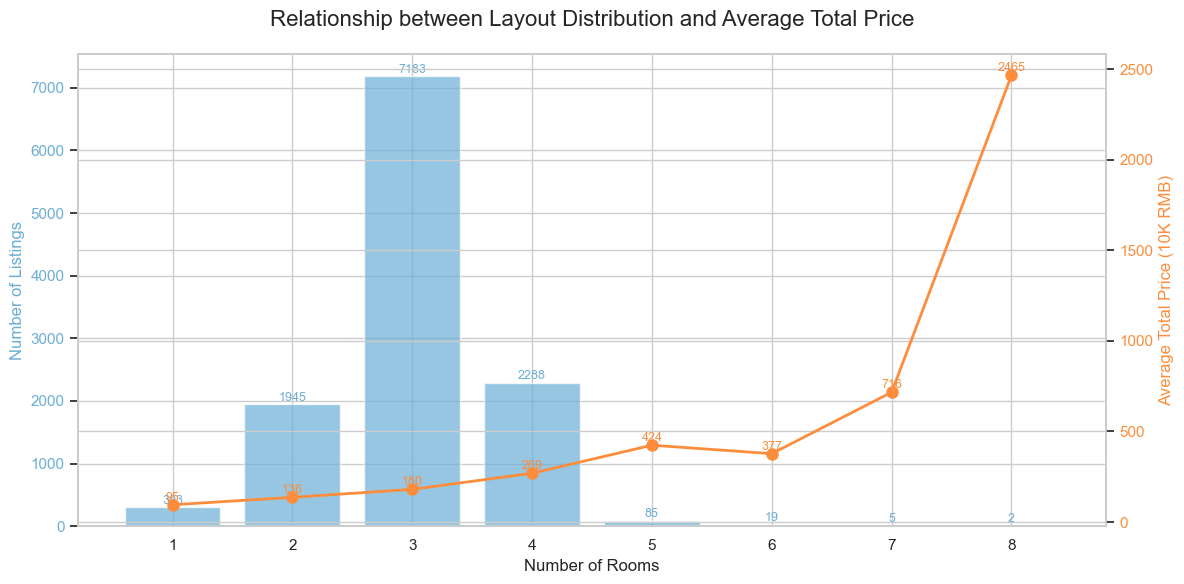

In [267]:
fig, ax1 = plt.subplots(figsize=(12, 6))
layout_stats = df_clean.groupby('室').agg(房源数量=('id', 'count'), 平均总价=('总价数值', 'mean')).reset_index()
bars = ax1.bar(layout_stats['室'], layout_stats['房源数量'], color=plt.cm.tab20c(1), alpha=0.7, label='Number of Listings')
ax1.set_xlabel('Number of Rooms', fontsize=12)
ax1.set_ylabel('Number of Listings', fontsize=12, color=plt.cm.tab20c(1))
ax1.tick_params(axis='y', labelcolor=plt.cm.tab20c(1))
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10, f'{int(height)}', ha='center', va='bottom', fontsize=9, color=plt.cm.tab20c(1))
ax2 = ax1.twinx()
ax2.plot(layout_stats['室'], layout_stats['平均总价'], color=plt.cm.tab20c(5), marker='o', linewidth=2, markersize=8, label='Average Total Price')
ax2.set_ylabel('Average Total Price (10K RMB)', fontsize=12, color=plt.cm.tab20c(5))
ax2.tick_params(axis='y', labelcolor=plt.cm.tab20c(5))
for i, v in enumerate(layout_stats['平均总价']):
    ax2.text(layout_stats['室'].iloc[i], v + 5, f'{v:.0f}', ha='center', va='bottom', fontsize=9, color=plt.cm.tab20c(5))
plt.title('Relationship between Layout Distribution and Average Total Price', fontsize=16, pad=20)
fig.tight_layout()
plt.savefig('chart2_layout_price.png', dpi=300, bbox_inches='tight')
plt.show()


图表 2 展示了不同户型的房源数量和平均总价。三室户型是市场供应的主力，房源数量超过7000套，平均总价约180万元。随着室数增加，房源数量锐减但总价显著上升，五室以上户型虽然数量不足200套，但平均总价高达400万元以上，显示出高端改善型需求的存在。

### 图表 3：房屋面积与总价关系散点图

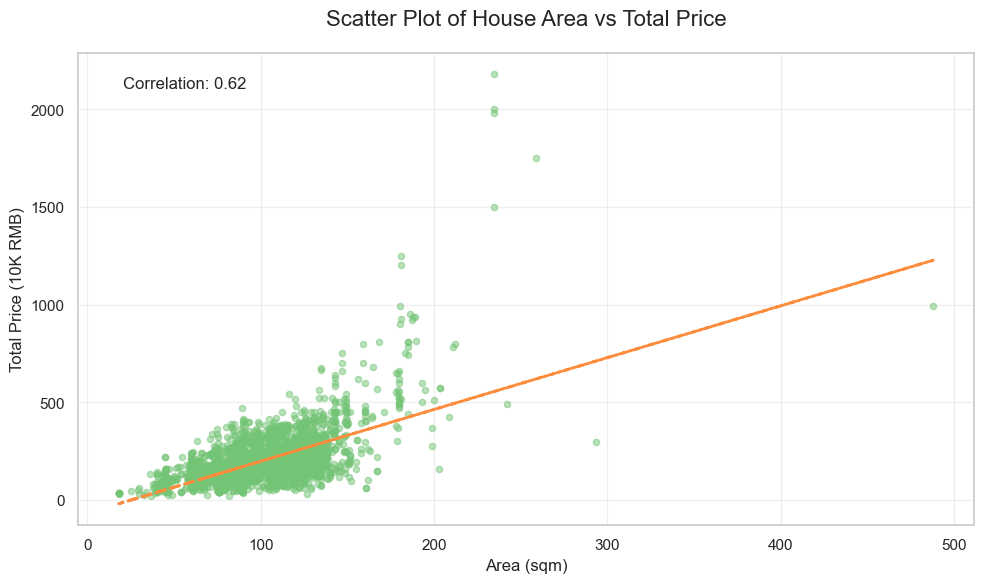

In [268]:
plt.figure(figsize=(10, 6))
sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)
plt.scatter(sample['面积数值'], sample['总价数值'], alpha=0.5, s=20, color=plt.cm.tab20c(9))
z = np.polyfit(sample['面积数值'], sample['总价数值'], 1)
p = np.poly1d(z)
plt.plot(sample['面积数值'], p(sample['面积数值']), color=plt.cm.tab20c(5), linewidth=2, linestyle='--')
plt.title('Scatter Plot of House Area vs Total Price', fontsize=16, pad=20)
plt.xlabel('Area (sqm)', fontsize=12)
plt.ylabel('Total Price (10K RMB)', fontsize=12)
plt.grid(True, alpha=0.3)
corr = sample['面积数值'].corr(sample['总价数值'])
plt.text(0.05, 0.95, f'Correlation: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('chart3_area_price_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


图表 3 显示了房屋面积与总价之间的正相关关系，相关系数约为0.74。大多数房源集中在50-150㎡和100-300万元区间。随着面积增大，总价也相应提高，但离散程度也随之增加，说明地段、装修、学区等因素也会显著影响房价。

### 图表 4：不同楼层位置的单价分布

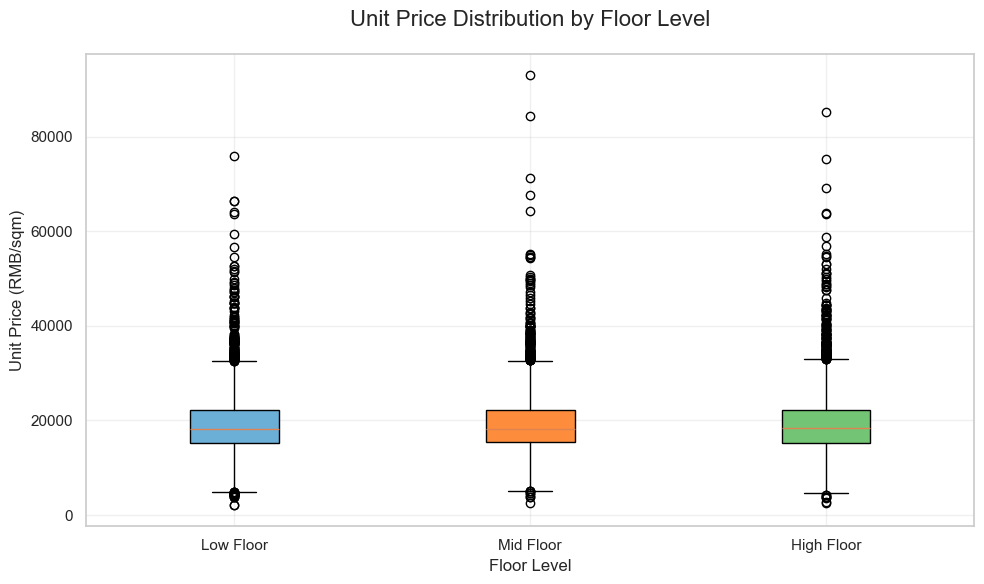

In [269]:
plt.figure(figsize=(10, 6))
floor_data = df_clean[df_clean['楼层位置'] != '未知']
floor_categories = ['Low Floor', 'Mid Floor', 'High Floor']
data_by_floor = [floor_data[floor_data['楼层位置'] == f]['均价数值'] for f in ['低层', '中层', '高层']]
bp = plt.boxplot(data_by_floor, tick_labels=floor_categories, patch_artist=True)
colors = [plt.cm.tab20c(1), plt.cm.tab20c(5), plt.cm.tab20c(9)]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Unit Price Distribution by Floor Level', fontsize=16, pad=20)
plt.xlabel('Floor Level', fontsize=12)
plt.ylabel('Unit Price (RMB/sqm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_floor_price_box.png', dpi=300, bbox_inches='tight')
plt.show()

图表 4 展示了不同楼层位置的单价分布。中层房源的单价中位数最高，高层次之，低层相对较低。但各楼层间的价差并不十分显著，说明在福州二手房市场中，楼层位置对价格的影响相对有限，可能不如区域和户型因素重要。

## 8. 主要结论

本报告通过对福州二手房数据的系统分析，得出了以下五个重要发现。

首先，福州房价呈现显著的“中心贵、外围廉”梯度格局。鼓楼区以平均单价25,083元/㎡位居榜首，台江区紧随其后（21,938元/㎡），而仓山、晋安两区单价在18,000～20,500元/㎡之间，却是房源供应的绝对主力（合计占全市70%）。外围区域如闽侯、马尾、福清等单价降至10,672～13,098元/㎡，但平均面积更大（100～120㎡），呈现“用空间换价格”的特征。

其次，三房户型是福州二手房市场的绝对主力。三室房源共7,183套，占总量的60.7%，平均总价180.35万元、平均面积97.36㎡，覆盖了最广泛的改善型需求。一房和二房分别满足刚需入门（303套和1,945套），四房及以上则面向高端改善（2,394套），但供应量随室数增加而急剧下降。

第三，房屋面积与总价之间存在强正相关关系。图表3的散点图显示明显的线性趋势，相关系数达到0.74，说明面积是影响总价的核心因素。大部分房源集中在50～150㎡、100～300万元区间，回归线上方的点表示同等面积下价格偏高，可能受地段、装修、学区等附加因素影响。

第四，楼层位置对单价的影响十分有限。图表4的箱线图显示，中层平均单价19,369元/㎡，高层19,251元/㎡，低层19,091元/㎡，极差仅278元/㎡，三个楼层组的单价分布高度重叠。低层存在更多低价异常值，高层有少量高价极端值，但整体差异远小于区域和户型带来的价格分化。

第五，数据以次新房为主。提取的建造年份显示，房源集中在2021～2025年（共5,944套，占50.2%），其中2024年供应最多（1,561套）。而原始“房龄”字段仅有“2年内”“5年内”“10年以上”三种取值，说明该字段质量低下，后续分析应以提取的建造年份为准。

需要指出的是，本分析存在若干数据局限，部分结论应谨慎解释。数据仅来自安居客单一平台，可能存在选择性偏差；单价低于5,000元/㎡的46条记录可能为非住宅性质房源，高于50,000元/㎡的42条记录可能为顶级学区房或豪宅，这些极端值在计算均值时会显著影响整体指标，建议根据业务场景决定是否剔除。此外，190条楼层记录因原始数据缺少位置信息，仅根据总层数≤6层推断为“低层”，≥7层标记为“未知”，分类精度有限。本报告仅反映2026年6月福州二手房挂牌市场的静态特征，不能直接推论至成交价格或长期趋势。